# Multi-slice DLPFC Integration

This tutorial integrates four consecutive DLPFC sections with within-slice and adjacent-slice topology. It assumes that the x/y coordinates are already registered and that `slice_order` follows the physical section order.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.spatial import spatial_reconstruction
from SpaDiff.utils import mclust_R, set_seed

## Configuration

In [4]:
SEED = 42
ST_SAMPLES = ["151673", "151674", "151675", "151676"]
# ST_SAMPLES = ["151669", "151670", "151671", "151672"]
# ST_SAMPLES = ["151507", "151508", "151509", "151510"]
# SAMPLE_ID = "7376"
BATCH_KEY = "batch_name"
REFERENCE_BATCH = ST_SAMPLES[0]
N_CLUSTERS = 7
TOPOLOGY_MODE = "slice_aware"  # Alternatives: "slice_aware" or "global_knn".
N_NEIGHBORS = 10
K_INTRA = 6
K_INTER = 2
training_epochs = 500
SECTION_SPACING = 1.0  # Unit spacing for the reconstructed z axis.

MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)

DATA_ROOT = Path("E:/gxy_2/final/0_data/case1")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)

DATA_ROOT = E:\gxy_2\final\0_data\case1
device = cuda:0


## Data loading and preprocessing

Each section is normalized before concatenation.

In [5]:
slices = []
for sample in ST_SAMPLES:
    sample_dir = DATA_ROOT / sample
    current = sc.read_visium(sample_dir)
    current.var_names_make_unique()
    current.layers["counts"] = current.X.copy()
    sc.pp.normalize_total(current, target_sum=1e4)
    sc.pp.log1p(current)

    current, _ = spatial_reconstruction(current, alpha=1.5, n_neighbors=N_NEIGHBORS)

    truth = pd.read_csv(sample_dir / "truth.txt", sep="\t", header=None, index_col=0)
    truth.columns = ["Truth"]
    current.obs["Truth"] = truth.reindex(current.obs_names)["Truth"]
    current.obs[BATCH_KEY] = sample
    current.obs_names = [f"{sample}:{barcode}" for barcode in current.obs_names]
    slices.append(current)

adata = sc.concat(slices, join="inner", merge="same")

xy = np.asarray(adata.obsm["spatial"], dtype=np.float32)
slice_to_z = {sample: index * SECTION_SPACING for index, sample in enumerate(ST_SAMPLES)}
z = adata.obs[BATCH_KEY].map(slice_to_z).to_numpy(dtype=np.float32)
adata.obsm["spatial_3d"] = np.column_stack((xy, z))

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts", n_top_genes=3000,batch_key=BATCH_KEY, subset=True)


adata

AnnData object with n_obs × n_vars = 14364 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Truth', 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'
    obsm: 'spatial', 'spatial_3d'
    layers: 'counts'

## Higher-order topology


In [6]:
topology = sd.build_spatial_topology(
    adata,
    mode=TOPOLOGY_MODE,
    spatial_key="spatial",
    batch_key=BATCH_KEY,
    slice_order=ST_SAMPLES,
    k_intra=K_INTRA,
    k_inter=K_INTER,
    n_neighbors=N_NEIGHBORS,
    max_order=MAX_ORDER,
    device=device,
)
operators = topology.operators

sc.tl.pca(adata, n_comps=50)
features = torch.as_tensor(adata.obsm["X_pca"], dtype=torch.float32, device=device)

Simplicial complex statistics:
  order 0 (vertices): 14,364
  order 1 (edges): 63,489
  order 2 (triangles): 48,847


## SpaDiff training

Each section is treated as a batch, and the first section is used as the harmonization reference.

In [7]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    num_batches=len(ST_SAMPLES),
    num_modalities=1,
    simplex_orders=SIMPLEX_ORDERS,
)
model = sd.SpaDiff(config).to(device)
adata = model.fit_transform(
    adata,
    features,
    operators,
    batch_key=BATCH_KEY,
    batch_order=ST_SAMPLES,
    reference_batch=REFERENCE_BATCH,
    epochs=training_epochs,
    progress=True,
)

Training SpaDiff: 100%|██████████| 500/500 [00:28<00:00, 17.83epoch/s]


In [8]:
labels = mclust_R(adata, num_cluster=N_CLUSTERS, used_obsm="spadiff", pca_num=20)
adata.obs["mclust"] = pd.Categorical(labels.astype(str))


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 5.4.10
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


ARI by slice: {'151673': 0.615, '151674': 0.668, '151675': 0.655, '151676': 0.654}
NMI by slice: {'151673': 0.729, '151674': 0.752, '151675': 0.722, '151676': 0.729}
overall ARI = 0.646
overall NMI = 0.726


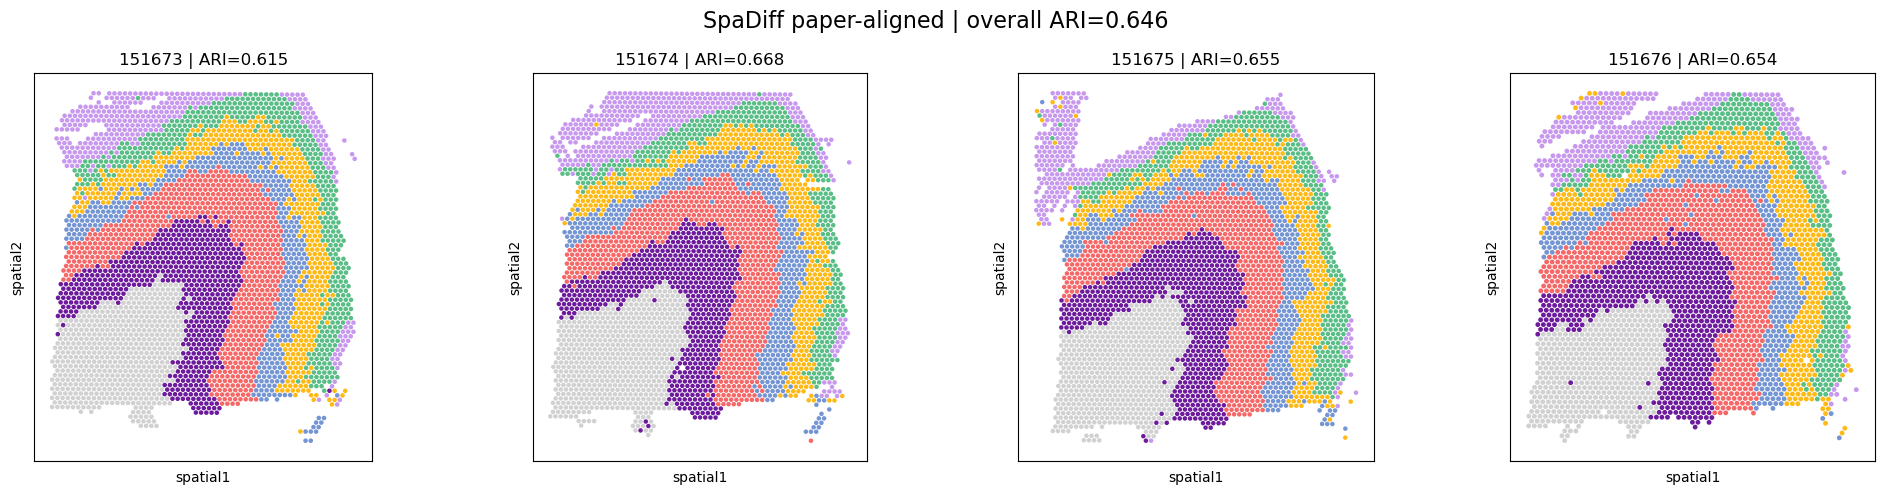

In [11]:
ari_by_slice = {}
nmi_by_slice = {}

for sample in ST_SAMPLES:
    current = adata.obs.loc[adata.obs[BATCH_KEY] == sample, ["Truth", "mclust"]].dropna()
    ari_by_slice[sample] = adjusted_rand_score(current["Truth"], current["mclust"])
    nmi_by_slice[sample] = normalized_mutual_info_score(current["Truth"], current["mclust"])
valid = adata.obs[["Truth", "mclust"]].dropna()

overall_ari = round(adjusted_rand_score(valid["Truth"], valid["mclust"]),4)
overall_nmi = round(normalized_mutual_info_score(valid["Truth"],valid["mclust"]),4)

print("ARI by slice:", {key: round(value, 3) for key, value in ari_by_slice.items()})
print("NMI by slice:",{key: round(value, 3) for key, value in nmi_by_slice.items()})

print(f"overall ARI = {overall_ari:.3f}")
print(f"overall NMI = {overall_nmi:.3f}")


palette = ["#6D1A9C", "#D1D1D1", "#F56867", "#59BE86", "#FEB915", "#C798EE", "#7495D3"]
fig, axes = plt.subplots(1, len(ST_SAMPLES), figsize=(5 * len(ST_SAMPLES), 5))
for axis, sample in zip(axes, ST_SAMPLES):
    current = adata[adata.obs[BATCH_KEY] == sample].copy()
    sc.pl.spatial(
        current, color="mclust", ax=axis, show=False, spot_size=120,
        palette=palette, legend_loc=None, title=f"{sample} | ARI={ari_by_slice[sample]:.3f}",
    )
fig.suptitle(f"SpaDiff paper-aligned | overall ARI={overall_ari:.3f}", fontsize=16)
plt.tight_layout()
# plt.savefig("../result/dlpfc_3d_domains.pdf", bbox_inches="tight")

In [ ]:
# output_file ="../result/spadiff_"+SAMPLE_ID+"_"+str(overall_ari)+".h5ad" 

# adata.write_h5ad(output_file, compression="gzip")